# Download CSDA Imagery

In [1]:
!pip install --user git+https://github.com/NASA-IMPACT/csda-client

  Cloning https://github.com/NASA-IMPACT/csda-client to /panfs/ccds02/nobackup/people/pmontesa/.nccstmp/pip-req-build-4r71xnac
  Running command git clone --filter=blob:none --quiet https://github.com/NASA-IMPACT/csda-client /panfs/ccds02/nobackup/people/pmontesa/.nccstmp/pip-req-build-4r71xnac
  Resolved https://github.com/NASA-IMPACT/csda-client to commit 3584c34672fc91beb219e774ce122dd1030e2a60
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Error while checking for conflicts. Please file an issue on pip's issue tracker: https://github.com/pypa/pip/issues/new
Traceback (most recent call last):
  File "/panfs/ccds02/app/modules/jupyter/ilab/jupyter-lab/ilab-juplab-ENV-current/lib/python3.12/site-packages/pip/_internal/commands/install.py", line 588, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/panfs/ccds02/app/

In [4]:
#!pip show fiona

In [2]:
#!pip install --user tabulate

In [1]:
#!pip install --user humanize

In [3]:
#!pip show tabulate

In [8]:
import os
import getpass
from pathlib import Path
from tempfile import TemporaryDirectory

import contextily
#import cql2
#import humanize
import rasterio
import rasterio.plot
import tabulate
import pandas as pd
import geopandas as gpd
from httpx import BasicAuth
#from pystac_client import Client

from csda_client import CsdaClient

Matplotlib is building the font cache; this may take a moment.


In [9]:
import humanize
from matplotlib_scalebar.scalebar import ScaleBar

In [10]:
import configparser
from pathlib import Path
from csda_client import CsdaClient
from httpx import BasicAuth

def load_earthdata_creds(path='/home/pmontesa/code/credentials.ini'):
    config = configparser.ConfigParser()
    config.read(Path(path).expanduser())
    return config['EarthData']['username'], config['EarthData']['password']

In [11]:
username, password = load_earthdata_creds()
client = CsdaClient.open(BasicAuth(username=username, password=password))
client.verify()

'Hello montesano, you have a valid token!'

In [12]:
profile = client.profile(username)
rows = []
for vendor in profile.vendors:
    rows.append([vendor.vendor, vendor.quota, vendor.quota_unit])
tabulate.tabulate(rows, headers=["Vendor", "Quota", "Quota unit"], tablefmt="html")

Vendor,Quota,Quota unit
Airbus U.S.- Optical,1000000000000,QuotaUnit.filesize
Planet,5000000,QuotaUnit.area
Satellogic,1000000000000,QuotaUnit.filesize
Vantor IKONOS (NASA only),-1,QuotaUnit.area
Vantor - WorldView 4 (NASA only),-1,QuotaUnit.filesize
Vantor Legion,1000000000000,QuotaUnit.filesize
Vantor (NASA only),-1,QuotaUnit.area


### Specifcy corresponding geodataframe and stac items from previous CSDA STAC search

In [13]:
# items_fn = '/home/pmontesa/code/csda_summaries/notebooks/stac_items_eval_airbus-optical_allyears.json'
# gdf_fn = '/home/pmontesa/code/csda_summaries/notebooks/stac_eval_airbus-optical_allyears.gpkg'

items_fn = '/home/pmontesa/code/csda_summaries/notebooks/stac_items_eval_maxar-legion_allyears.json'
gdf_fn = '/home/pmontesa/code/csda_summaries/notebooks/stac_eval_maxar-legion_allyears.gpkg'

### Load STAC items

In [22]:
from pystac import ItemCollection

ic = ItemCollection.from_file(items_fn)
stac_items = list(ic.items)

#### Check: select an image using an index

In [23]:
IMAGE_INDEX = 0

In [138]:
item = stac_items[IMAGE_INDEX]
item

<Item id=200010856946_01_P001_S3DS>

Text(0.5, 1.0, 'maxar-legion: 200010856946_01_P001_S3DS')

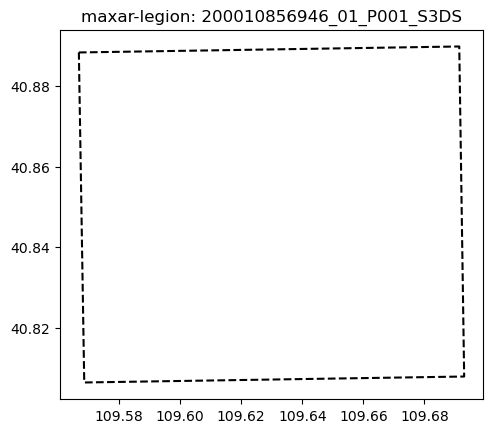

In [20]:
stac_gdf = gpd.read_file(gdf_fn)
stac_gdf_subset = stac_gdf.iloc[IMAGE_INDEX:IMAGE_INDEX+1]
ax = stac_gdf_subset.plot(
                facecolor='none',
                edgecolor='black',
                linestyle='--',
                linewidth=1.5,
                zorder=3
            )
ax.set_title(f"{stac_gdf_subset.collection[0]}: {stac_gdf_subset.id[0]}")

## Select images for download
Before downloading, do whatever filtering is needed of the input set search results (using either the gdf or the items)

In [24]:
SELECTED_ID_LIST = stac_gdf[stac_gdf['csda:band_count'] == 8].id.to_list() # Maxar Legion

## Download data

#### Choice:
+ download sidecar files only
+ download everything (incl tif files)

In [121]:
# Filter the original stac_items list to keep only the matching ID
STAC_ITEMS_DOWNLOAD = [item for item in stac_items if item.id in SELECTED_ID_LIST]

print(f"Matched {len(STAC_ITEMS_DOWNLOAD)} STAC item(s).")

Matched 62 STAC item(s).


In [122]:
DOWNLOAD_ALL = True

In [123]:
OUT_MAIN_DIR = f'/explore/nobackup/projects/CSDA_eval/csda_download/test'

In [124]:
import sys
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
import csdalib_download

In [139]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import pandas as pd

records = []

# --- NEW SAFEGUARD: Pre-create target subdirectories ---
# This ensures OS handles are open and paths exist before threads try to write to them
for item in STAC_ITEMS_DOWNLOAD:
    target_path = f'{OUT_MAIN_DIR}/{item.id}'
    os.makedirs(target_path, exist_ok=True)

with ThreadPoolExecutor(max_workers=20) as pool:
    if DOWNLOAD_ALL:
        futures = {
            pool.submit(
                csdalib_download.download_all_assets, 
                item, 
                client, 
                f'{OUT_MAIN_DIR}/{item.id}'
            ): item for item in STAC_ITEMS_DOWNLOAD
        }
    else:
        futures = {
            pool.submit(
                csdalib_download._process_one_item, 
                item, 
                client, 
                f'{OUT_MAIN_DIR}/{item.id}'
            ): item for item in STAC_ITEMS_DOWNLOAD
        }
        
    for future in as_completed(futures):
        item = futures[future]
        try:
            # Resolving the future results
            res = future.result()
            if res is not None:
                records.append(res)
            print(f"Successfully processed: {item.id}")
        except Exception as e:
            print(f'Error on {item.id}: {e}')

# Protect against empty lists crashing the DataFrame generator
if records:
    products_df = pd.DataFrame(records)
else:
    products_df = pd.DataFrame()
    print("Warning: No records were returned from the downloads.")


ERROR! Session/line number was not unique in database. History logging moved to new session 5556
  ✓ IMD                   → 25APR09152934-M3DS-200012699716_01_P001.IMD
  ✓ IMD                   → 25APR09152934-M3DS-200012699716_01_P001.IMD
  ✓ IMD                   → 24NOV03002132-M3DS-200010964783_01_P001.IMD
  ✓ IMD                   → 24NOV03002132-M3DS-200010964783_01_P001.IMD
  ✓ IMD                   → 25MAR14091622-M3DS-200009817643_01_P001.IMD
  ✓ IMD                   → 25MAY27115351-M2AS-200012660302_01_P001.IMD
  ✓ IMD                   → 25MAR17091815-M2AS-200012660272_01_P001.IMD
  ✓ IMD                   → 25MAR14091622-M2AS-200012660223_01_P001.IMD
  ✓ IMD                   → 25SEP12123552-M3DS-200012699713_01_P001.IMD
  ✓ IMD                   → 25SEP12123552-M3DS-200012699713_01_P001.IMD
  ✓ IMD                   → 25MAR17091815-M3DS-200009817645_01_P001.IMD
  ✓ IMD                   → 25MAY20070723-M2AS-200012660299_01_P001.IMD
  ✓ IMD                   → 25MAY200707

In [99]:
products_df['visual-ned-r1c1'].to_list()[0]

PosixPath('/explore/nobackup/projects/CSDA_eval/csda_download/test/PNEO3_202108150346132_MS-FS_ORT_RFL/IMG_PNEO3_STD_202108150346138_MS-FS_ORT_PWOI_000635324_1_1_F_1_NED_R1C1.TIF')

### Misc

In [88]:
ID_TEST = SELECTED_ID_LIST[1]
ID_TEST

'PNEO3_202108150346132_MS-FS_ORT_RFL'

In [40]:
# Match the current STAC item to a row in your gdf
stac_gdf_subset = stac_gdf[stac_gdf['id'] == ID_TEST]
row = stac_gdf_subset.iloc[0]

item_id     = row['id']
collection  = row['collection']
date_str    = str(row['datetime'])[:10]   # first 10 chars = YYYY-MM-DD

In [46]:
item

<Item id=PNEO3_202509141756549_PAN_ORT_RFL>

## Plot images  
Notes:  
+ some Planet has only 3 data bands??? The 4th band looks like an Alpha channel? (looks like a data/nodata mask)
+ Airbus NIR-R-G will be [3,2,1] for a 4-band image - but the 'NIR' channel is labelled as 'Alpha' in metadata

In [96]:
def plot_image(local_path, stac_gdf, sites_gdf, item_id,
               rgb_indices=[0, 1, 2], max_dim=1024, ax=None):

    import matplotlib.pyplot as plt
    import rasterio
    from rasterio.plot import show
    from rasterio.warp import transform_bounds, calculate_default_transform, reproject, Resampling
    import contextily as ctx
    import numpy as np
    from matplotlib.ticker import MaxNLocator
    from pyproj import Transformer
    from matplotlib.offsetbox import AnchoredText
    from matplotlib_scalebar.scalebar import ScaleBar
    from shapely.geometry import box
    import os

    print(f'Plotting: {local_path}')
    
    # Filter STAC entry safely without overwriting the parent dataframe variable
    item_gdf = stac_gdf[stac_gdf.id == item_id].iloc[0:1]
    
    if len(item_gdf) == 0:
        print(f"⚠️ Warning: {item_id} not found in stac_gdf")
        return

    collection = item_gdf.collection.iloc[0] if 'collection' in item_gdf.columns else 'Unknown Collection'
    date_str = item_gdf.datetime.iloc[0] if 'datetime' in item_gdf.columns else ''

    try:
        with rasterio.open(local_path) as dataset:
            # 1. Calculate downsampled target dimensions
            h, w = dataset.height, dataset.width
            if max(h, w) > max_dim:
                scale = max_dim / float(max(h, w))
                out_h, out_w = int(h * scale), int(w * scale)
            else:
                out_h, out_w = h, w

            # 2. Read ONLY the downsampled array into memory
            data = dataset.read(
                out_shape=(dataset.count, out_h, out_w),
                resampling=Resampling.bilinear
            )

            # Calculate scaled source transform for the downsampled array
            src_transform = dataset.transform * dataset.transform.scale(
                (w / out_w),
                (h / out_h)
            )

            nodata = dataset.nodata
            dst_crs = 'EPSG:3857'

            # 3. Compute destination transform and dimensions for Web Mercator (EPSG:3857)
            dst_transform, dst_width, dst_height = calculate_default_transform(
                dataset.crs, dst_crs, out_w, out_h, *dataset.bounds
            )

            left, bottom, right, top = transform_bounds(
                dataset.crs, dst_crs, *dataset.bounds
            )

            # 4. Fast Reprojection of downsampled bands
            reprojected = np.zeros((dataset.count, dst_height, dst_width), dtype=data.dtype)
            for i in range(dataset.count):
                reproject(
                    source=data[i],
                    destination=reprojected[i],
                    src_transform=src_transform,
                    src_crs=dataset.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.bilinear,
                )

            # 5. Mask nodata values
            if nodata is not None:
                mask_reproj = np.any(reprojected == nodata, axis=0)
            else:
                mask_reproj = np.all(reprojected == 0, axis=0)

            # Create figure/ax only if ax wasn't passed in
            standalone_plot = False
            if ax is None:
                fig, ax = plt.subplots(figsize=(14, 10))
                standalone_plot = True

            ax.set_xlim(left, right)
            ax.set_ylim(bottom, top)

            # Add Basemap
            ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas,
                            crs=dst_crs, attribution=' ')

            # Safe RGB selection (fallback if requested bands exceed available count)
            valid_rgb = [idx for idx in rgb_indices if idx < dataset.count]
            if len(valid_rgb) < 3:
                valid_rgb = list(range(min(3, dataset.count)))

            img_rgb = np.moveaxis(reprojected[valid_rgb], 0, -1)

            # 6. Contrast Stretch (2nd to 98th percentile)
            img_stretched = np.zeros_like(img_rgb, dtype=np.uint8)
            for i in range(img_rgb.shape[-1]):
                band = img_rgb[..., i].astype(np.float32)
                valid = band[~mask_reproj]
                if len(valid) > 0:
                    p2, p98 = np.percentile(valid, [2, 98])
                else:
                    p2, p98 = band.min(), band.max()
                stretched = np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1) * 255
                img_stretched[..., i] = stretched.astype(np.uint8)

            alpha = (~mask_reproj * 255).astype(np.uint8)
            
            # Tile RGBA channels
            if img_stretched.shape[-1] == 3:
                rgba = np.dstack([img_stretched, alpha])
            else:
                rgba = img_stretched

            ax.imshow(rgba, extent=(left, right, bottom, top), zorder=2)

            # 7. Plot STAC Footprint
            item_gdf.to_crs(3857).plot(
                ax=ax,
                facecolor='none',
                edgecolor='black',
                linestyle='--',
                linewidth=2.5,
                zorder=3,
            )

            # 8. Plot Intersecting Sites
            raster_footprint_3857 = box(left, bottom, right, top)
            sites_3857 = sites_gdf.to_crs('EPSG:3857')
            intersecting_sites = sites_3857[sites_3857.intersects(raster_footprint_3857)]

            if len(intersecting_sites) > 0:
                intersecting_sites.plot(
                    ax=ax,
                    facecolor='none',
                    edgecolor='red',
                    linestyle='--',
                    linewidth=1.5,
                    zorder=3,
                )

                for _, s in intersecting_sites.iterrows():
                    c = s.geometry.centroid
                    ax.annotate(
                        str(s.get('site_name', s.get('name', 'Site'))),
                        xy=(c.x, c.y),
                        fontsize=9, color='red', weight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  alpha=0.7, edgecolor='none'),
                        zorder=4,
                    )

            # 9. Axis ticks -> Lat/Lon
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

            transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

            x_ticks = ax.get_xticks()
            mid_y = (bottom + top) / 2
            lons, _ = transformer.transform(x_ticks, [mid_y] * len(x_ticks))
            ax.set_xticklabels([f"{lon:.3f}°" for lon in lons])

            y_ticks = ax.get_yticks()
            mid_x = (left + right) / 2
            _, lats = transformer.transform([mid_x] * len(y_ticks), y_ticks)
            ax.set_yticklabels([f"{lat:.3f}°" for lat in lats])

            ax.set_xlabel('Longitude', fontsize=9, labelpad=4)
            ax.set_ylabel('Latitude', fontsize=9, labelpad=4)
            ax.tick_params(axis='both', which='major', labelsize=8)

            scalebar = ScaleBar(dx=1, units='m', location='lower right', length_fraction=0.2, box_alpha=0.7)
            ax.add_artist(scalebar)

            ax.set_title(f'{collection} | {date_str}',
                         fontsize=10, color='#333', loc='left', pad=6)

            ax.annotate(os.path.basename(local_path),
                        xy=(0.02, 0.02), xycoords='axes fraction',
                        fontsize=8, color='#555',
                        verticalalignment='bottom',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    except Exception as e:
        print(f"⚠️ Error rendering {local_path}: {e}")
        if ax is not None:
            ax.text(0.5, 0.5, f"Render Error\n{item_id}", ha='center', va='center', color='red', transform=ax.transAxes)

    if standalone_plot:
        plt.show()

In [97]:
OUT_MAIN_DIR

'/explore/nobackup/projects/CSDA_eval/csda_download/test'

In [103]:
plot_image(products_df['visual-ned-r1c1'].to_list()[0], stac_gdf, None, 'PNEO3_STD_202108150346138_MS-FS_ORT', rgb_indices = [2,1,0], max_dim=256)

Plotting: /explore/nobackup/projects/CSDA_eval/csda_download/test/PNEO3_202108150346132_MS-FS_ORT_RFL/IMG_PNEO3_STD_202108150346138_MS-FS_ORT_PWOI_000635324_1_1_F_1_NED_R1C1.TIF
⚠️ Warning: PNEO3_STD_202108150346138_MS-FS_ORT not found in stac_gdf


rgba shape: (7861, 7833, 4), dtype: uint8


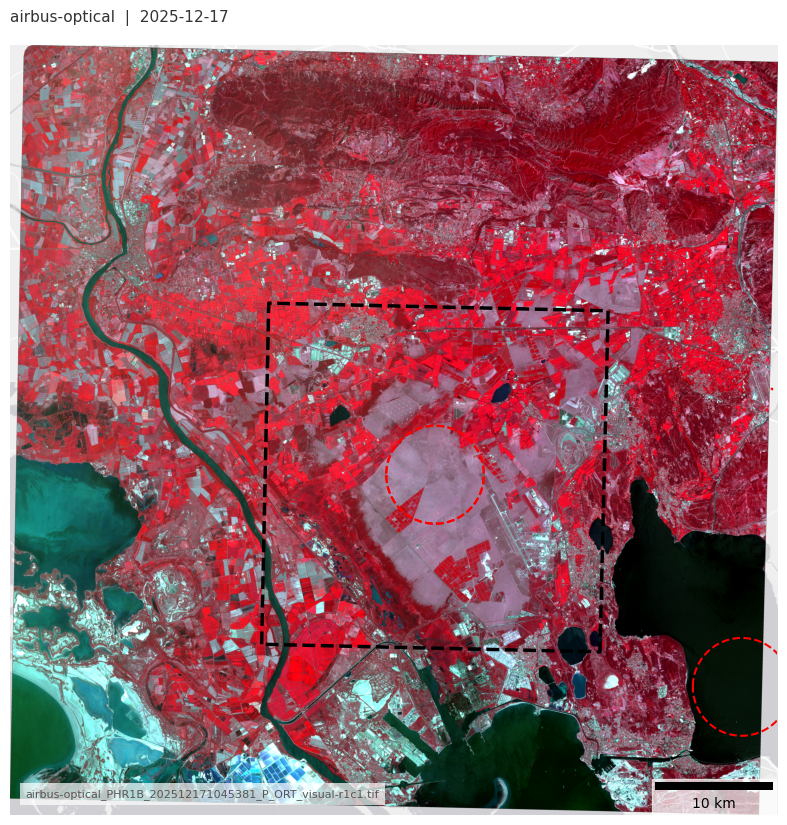

In [146]:
plot_image(local_path, stac_gdf_subset, sites_gdf, rgb_indices = [3,2,1])

rgba shape: (7736, 2783, 4), dtype: uint8
⚠️  No site intersects this image


/panfs/ccds02/app/modules/jupyter/ilab/dev/kernel/lib/python3.12/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


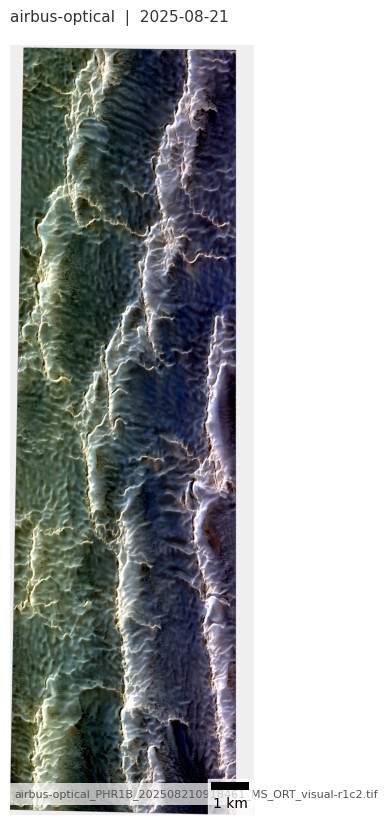

In [84]:
plot_image(local_path, stac_gdf_subset, sites_gdf, rgb_indices = [2,1,0])

rgba shape: (7850, 7809, 4), dtype: uint8
⚠️  No site intersects this image


/panfs/ccds02/app/modules/jupyter/ilab/dev/kernel/lib/python3.12/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


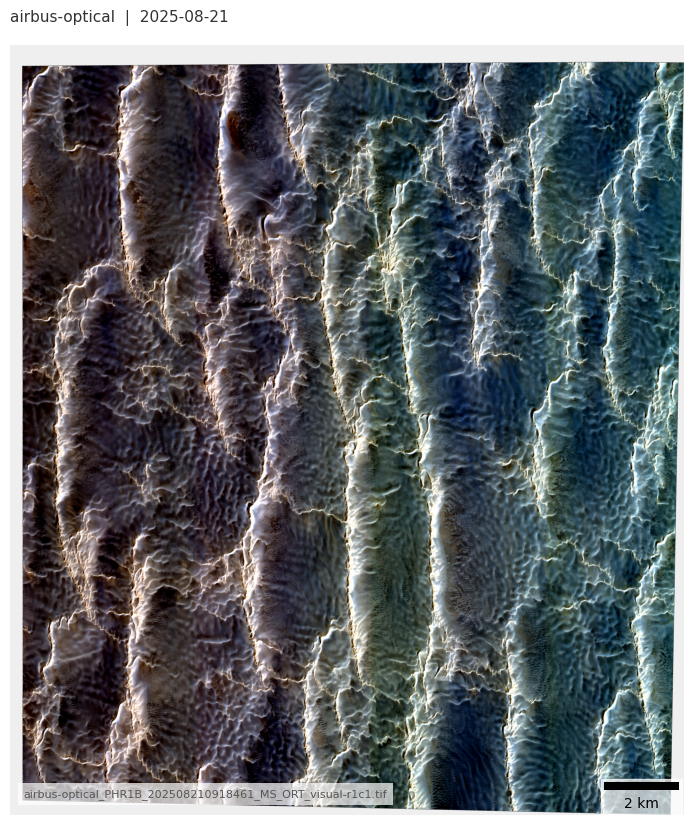

In [82]:
plot_image(local_path, stac_gdf_subset, sites_gdf, rgb_indices = [2,1,0])

rgba shape: (5440, 9013, 4), dtype: uint8


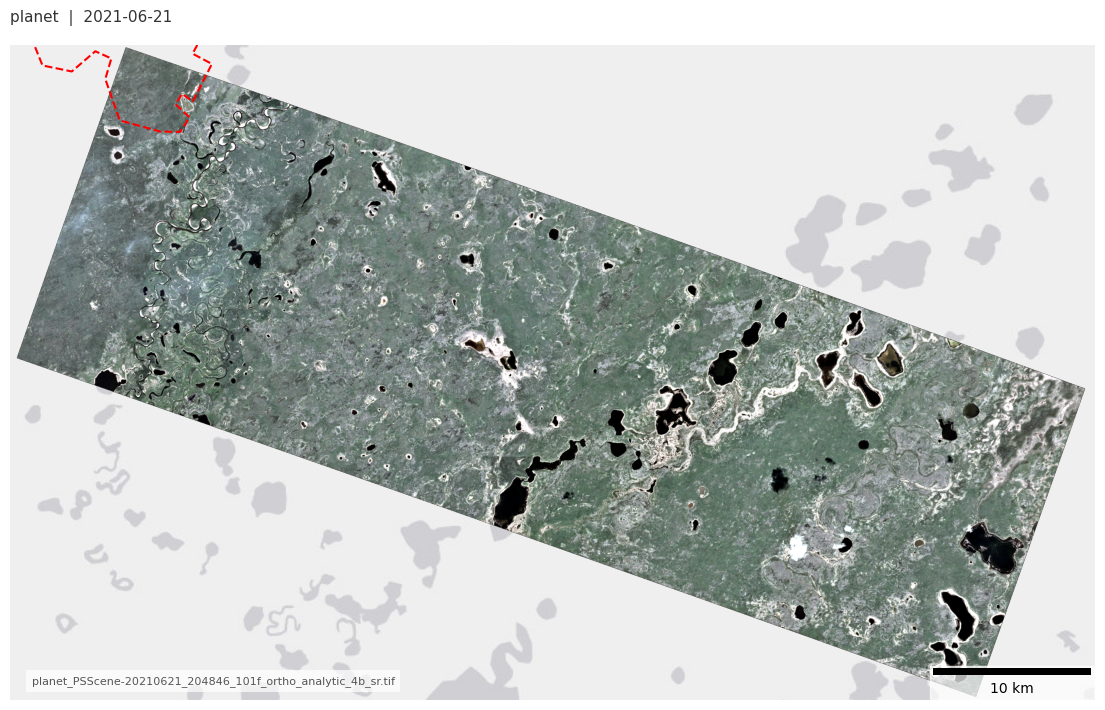

In [119]:
plot_image(local_path, stac_gdf, sites_gdf)